# Phase 8: Model Saving and Prediction

In this phase, I will save the trained CNN model and learn how to load it again without retraining.

The main goals of this phase are:

- Load and preprocess the MNIST dataset
- Build and train the CNN model
- Save the trained model to the `models/` folder
- Load the saved model again
- Make predictions using the loaded model
- Confirm that the saved model works correctly

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

In [4]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

c:\Users\User\Desktop\handwritten-digit-recognition\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9413 - loss: 0.1975 - val_accuracy: 0.9725 - val_loss: 0.0943
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9789 - loss: 0.0684 - val_accuracy: 0.9794 - val_loss: 0.0689
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9858 - loss: 0.0456 - val_accuracy: 0.9809 - val_loss: 0.0633
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9819 - val_loss: 0.0590
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9924 - loss: 0.0226 - val_accuracy: 0.9845 - val_loss: 0.0585


In [8]:
from pathlib import Path

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

model_path = project_root / "models" / "cnn_mnist_model.keras"
model_path.parent.mkdir(parents=True, exist_ok=True)

cnn_model.save(str(model_path))

In [9]:
loaded_model = load_model(str(model_path))

In [10]:
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(x_test_cnn, y_test)

print("Loaded model test loss:", loaded_test_loss)
print("Loaded model test accuracy:", loaded_test_accuracy)
print("Loaded model test accuracy (%):", loaded_test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9842 - loss: 0.0510
Loaded model test loss: 0.050976600497961044
Loaded model test accuracy: 0.9842000007629395
Loaded model test accuracy (%): 98.42000007629395


In [11]:
loaded_y_prob = loaded_model.predict(x_test_cnn)
loaded_y_pred = np.argmax(loaded_y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
print("First 10 true labels:")
print(y_test[:10])

print("First 10 loaded model predictions:")
print(loaded_y_pred[:10])

First 10 true labels:
[7 2 1 0 4 1 4 9 5 9]
First 10 loaded model predictions:
[7 2 1 0 4 1 4 9 5 9]


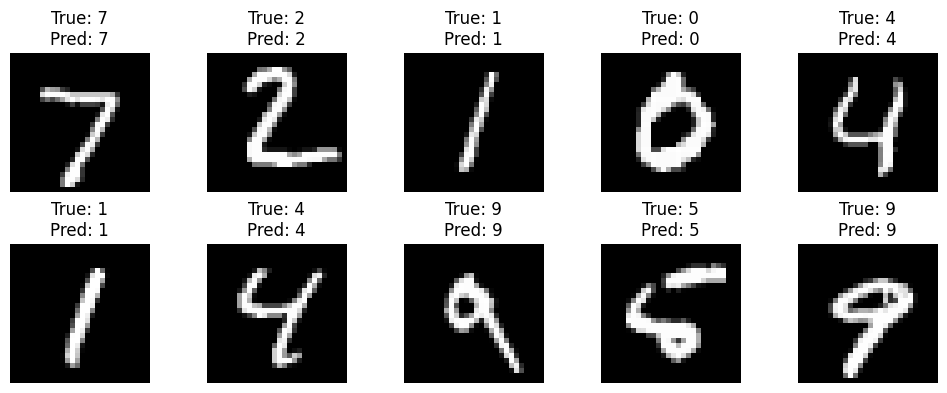

In [14]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {y_test[i]}\nPred: {loaded_y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Saving and Loading the CNN Model

After training the CNN model, I saved it using the `.keras` format.

Saving the model allows me to reuse it later without retraining from zero.

The saved model includes:

- The model architecture
- The learned weights
- The training configuration
- The optimizer state

After saving the model, I loaded it again using `load_model()` and confirmed that it can still evaluate the test set and make predictions correctly.

This is important because saved models can be reused later in prediction scripts, applications, or deployment.

## Phase 8 Summary: Model Saving and Prediction

In this phase, I trained a CNN model, saved it, loaded it again, and confirmed that the loaded model works correctly.

### Completed Tasks

- Loaded the MNIST dataset
- Normalized pixel values from 0–255 to 0–1
- Reshaped images into CNN format `(28, 28, 1)`
- Built the CNN architecture
- Compiled the CNN model
- Trained the CNN for 5 epochs
- Saved the trained model in `.keras` format
- Loaded the saved model using `load_model()`
- Evaluated the loaded model on the test set
- Made predictions using the loaded model
- Visualized loaded model predictions

### Key Observation

Saving the model allows it to be reused later without retraining.

The loaded model was able to evaluate the test set and make predictions correctly, confirming that the saving and loading process worked.

This step is important for future deployment because applications usually use a saved model file rather than training a model every time.